# 📊 04 — Estimación VAR/SVAR, Diagnósticos y Análisis Estructural

| Sección | Contenido |
|---------|-----------|
| 1 | Configuración (**única celda a editar**) |
| 2 | Cargar DATA_VAR |
| 3 | Estimación VAR(p) |
| 4 | Diagnósticos: normalidad, autocorrelación, ARCH |
| 5 | Causalidad de Granger |
| 6 | Identificación estructural (Cholesky) |
| 7 | IRF — Funciones Impulso-Respuesta |
| 8 | FEVD — Descomposición de varianza |
| 9 | Pronósticos |

> ✏️ **Solo edita la sección 1.**

---
## 1 · Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUTA_FUNC = os.path.abspath(os.path.join('.', 'funciones'))
if RUTA_FUNC not in sys.path:
    sys.path.insert(0, RUTA_FUNC)

from funciones_var_svar import (
    estimar_var, resumen_var, coeficientes_var, r2_rmse_var,
    diagnosticos_completos, granger_tabla, plot_granger_heatmap,
    identificacion_cholesky, plot_irf, plot_irf_custom,
    tabla_fevd, plot_fevd, pronosticar, plot_pronosticos,
)

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA', 'axes.edgecolor': '#CCCCCC',
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 1.0,
    'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
})
print('Imports OK')

Imports OK


---
## ✏️ 2 · Configuración — **Edita solo aquí**

In [9]:
# ── Ruta al Excel preparado por el notebook 03 ────────────────────────
RUTA_DATA = 'data/DATA_DESTACIONALIZADA.xlsx'

# ── Variables a incluir en el VAR (en el orden del sistema) ──────────
RENAME = {
    'Expectativas Empresariales (3m)' : 'Expec',
    'Tasa de Referencia BCRP (%)'     : 'Tasa',
    'Crecimiento PBI (% interanual)'  : 'PBI',
    'Términos de Intercambio (var%)'  : 'TInt',
}
VARS_ = list(RENAME.values())  # ['Expec', 'Tasa', 'PBI', 'TInt']

data = pd.read_excel(RUTA_DATA, index_col=0, parse_dates=True)
print(list(data.columns)) 
data = data.apply(pd.to_numeric, errors='coerce').dropna()
data = pd.read_excel(RUTA_DATA, index_col=0, parse_dates=True)
print(f'Data cargada : {data.shape[0]} obs x {data.shape[1]} variables')
print(f'Rango        : {data.index.min().date()} -> {data.index.max().date()}')
print(f'Variables    : {list(data.columns)}')
data.tail()
# ── Rezagos: None = selección automática, o un entero (ej. 2) ────────
P = None          # None → selección automática por criterio IC
IC = 'bic'        # criterio: 'aic', 'bic', 'hqic'
MAX_LAGS = 8      # máximo de rezagos a evaluar

# ── Parámetros de análisis ────────────────────────────────────────────
ALPHA    = 0.05   # nivel de significancia
IRF_STEPS = 20    # horizonte IRF y FEVD
FORE_STEPS = 12   # pasos de pronóstico

['Expectativas Empresariales (3m)', 'Tasa de Referencia BCRP (%)', 'Crecimiento PBI (% interanual)', 'Términos de Intercambio (var%)']
Data cargada : 253 obs x 4 variables
Rango        : 2004-01-01 -> 2025-01-01
Variables    : ['Expectativas Empresariales (3m)', 'Tasa de Referencia BCRP (%)', 'Crecimiento PBI (% interanual)', 'Términos de Intercambio (var%)']


---
## 3 · Cargar DATA_VAR

In [12]:
# Lee y renombra
data = pd.read_excel(RUTA_DATA, index_col=0, parse_dates=True)
data.columns = ['Expec', 'Tasa', 'PBI', 'TInt']  # renombra directo por posicion
data = data.apply(pd.to_numeric, errors='coerce').dropna()
VARS_ = list(data.columns)

print(f'Columnas: {VARS_}')
print(f'Shape: {data.shape}')

# Estima directo
model, results = estimar_var(data, VARS_, p=P, ic=IC, max_lags=MAX_LAGS)
resumen_var(results, VARS_)
p_opt = results.k_ar

Columnas: ['Expec', 'Tasa', 'PBI', 'TInt']
Shape: (253, 4)
✅ Lag óptimo seleccionado por BIC: p = 2
  Modelo VAR(2) — Resultados Generales
  Variables  : ['Expec', 'Tasa', 'PBI', 'TInt']
  Rezagos    : 2
  Obs efectivas : 251
  Log-likelihood: -1962.6767
  AIC  = 4.57420
  HQIC = 4.77769
  SBIC = 5.07985


C:\Users\LUZ\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


---
## 4 · Estimación VAR(p)

In [11]:
model, results = estimar_var(data, VARS_, p=P, ic=IC, max_lags=MAX_LAGS)
resumen_var(results, VARS_)

KeyError: "None of [Index(['Expec', 'Tasa', 'PBI', 'TInt'], dtype='object')] are in the [columns]"

In [13]:
coeficientes_var(results)


📋 Coeficientes por ecuación
─────────────────────────────────────────────────────────────────

  Ecuación dependiente: Expec
Variable    Coef.  Std.Err.      t  P>|t| Sig.
   const  0.08072   0.08443  0.956 0.3390     
L1.Expec  1.47312   0.05675 25.957 0.0000  ***
 L1.Tasa  0.00318   0.00345  0.921 0.3572     
  L1.PBI -0.00213   0.00353 -0.605 0.5454     
 L1.TInt -0.01616   0.00660 -2.449 0.0143   **
L2.Expec -0.49499   0.05660 -8.745 0.0000  ***
 L2.Tasa -0.00306   0.00347 -0.881 0.3782     
  L2.PBI  0.00388   0.00346  1.120 0.2626     
 L2.TInt -0.00677   0.00671 -1.010 0.3124     

  Ecuación dependiente: Tasa
Variable    Coef.  Std.Err.      t  P>|t| Sig.
   const  3.98277   1.59748  2.493 0.0127   **
L1.Expec -0.85729   1.07388 -0.798 0.4247     
 L1.Tasa  0.93824   0.06526 14.376 0.0000  ***
  L1.PBI  0.02964   0.06676  0.444 0.6571     
 L1.TInt  0.23776   0.12484  1.905 0.0568    *
L2.Expec  0.86576   1.07105  0.808 0.4189     
 L2.Tasa -0.01170   0.06575 -0.178 0.8587    

In [14]:
tabla_ajuste = r2_rmse_var(results, data, VARS_)


📊 Ajuste por ecuación
Variable  Parms   RMSE     R²
   Expec      9 0.2291 0.9826
    Tasa      9 4.3353 0.8580
     PBI      9 4.0867 0.6784
    TInt      9 2.2082 0.0846


---
## 5 · Diagnósticos

In [15]:
df_norm, df_lb, df_arch = diagnosticos_completos(results, alpha=ALPHA)


🔍 Normalidad — Jarque–Bera por ecuación
    Variable    JB stat    p-value     Skew     Kurt   Normal?
  ────────────────────────────────────────────────────────────
       Expec    613.740    0.00000    0.769   10.505         ❌
        Tasa   1870.789    0.00000   -1.653   15.959         ❌
         PBI  15914.833    0.00000    3.069   41.524         ❌
        TInt    152.336    0.00000    0.275    6.777         ❌

  Anderson–Darling global: stat=inf, p=0.00000  ❌

🔍 Autocorrelación — Ljung–Box (lag=10) por ecuación
    Variable    LB stat    p-value   Sin autocorr?
  ──────────────────────────────────────────────────
       Expec     19.315    0.03644               ❌
        Tasa     10.453    0.40168               ✅
         PBI     13.182    0.21369               ✅
        TInt     21.253    0.01940               ❌

🔍 Heterocedasticidad — ARCH (lag=5) por ecuación
    Variable   F stat      p(F)      Chi²     p(Chi²)   Homoc.?
  ─────────────────────────────────────────────────────

---
## 6 · Causalidad de Granger

In [16]:
granger_df = granger_tabla(data, VARS_, max_lag=results.k_ar, alpha=ALPHA)


📋 Test de Causalidad de Granger
   Lag = 2  |  α = 0.05
Dependiente Excluida    Chi²  gl  p-value Granger →
      Expec      PBI  1.7643   2  0.41389      ❌ No
      Expec     TInt  8.1379   2  0.01710      ✅ Sí
      Expec     Tasa  0.2307   2  0.89105      ❌ No
        PBI    Expec  4.9918   2  0.08242      ❌ No
        PBI     TInt  0.8773   2  0.64490      ❌ No
        PBI     Tasa  8.3885   2  0.01508      ✅ Sí
       TInt    Expec  5.4526   2  0.06546      ❌ No
       TInt      PBI  6.2080   2  0.04487      ✅ Sí
       TInt     Tasa  4.1000   2  0.12873      ❌ No
       Tasa    Expec  2.7610   2  0.25145      ❌ No
       Tasa      PBI  2.8184   2  0.24434      ❌ No
       Tasa     TInt 14.1588   2  0.00084      ✅ Sí


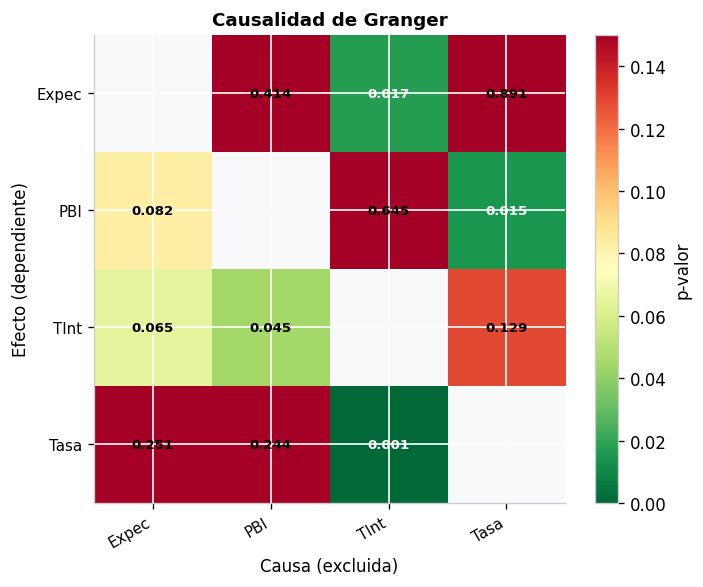

In [17]:
plot_granger_heatmap(granger_df, alpha=ALPHA)

---
## 7 · Identificación estructural (Cholesky)

In [18]:
P_chol = identificacion_cholesky(results, VARS_)


🔧 Identificación estructural — Cholesky

  Σ_u — Matriz de covarianza de residuos:
          Expec       Tasa        PBI      TInt
Expec  0.054445   0.099388   0.161939 -0.001675
Tasa   0.099388  19.493384   4.332816  0.903366
PBI    0.161939   4.332816  17.322069 -0.166334
TInt  -0.001675   0.903366  -0.166334  5.057506

  P — Matriz de impacto estructural (triangular inferior):
          Expec      Tasa       PBI      TInt
Expec  0.233335  0.000000  0.000000  0.000000
Tasa   0.425944  4.394537  0.000000  0.000000
PBI    0.694020  0.918687  3.999552  0.000000
TInt  -0.007179  0.206261 -0.087720  2.237681


---
## 8 · IRF — Funciones Impulso-Respuesta

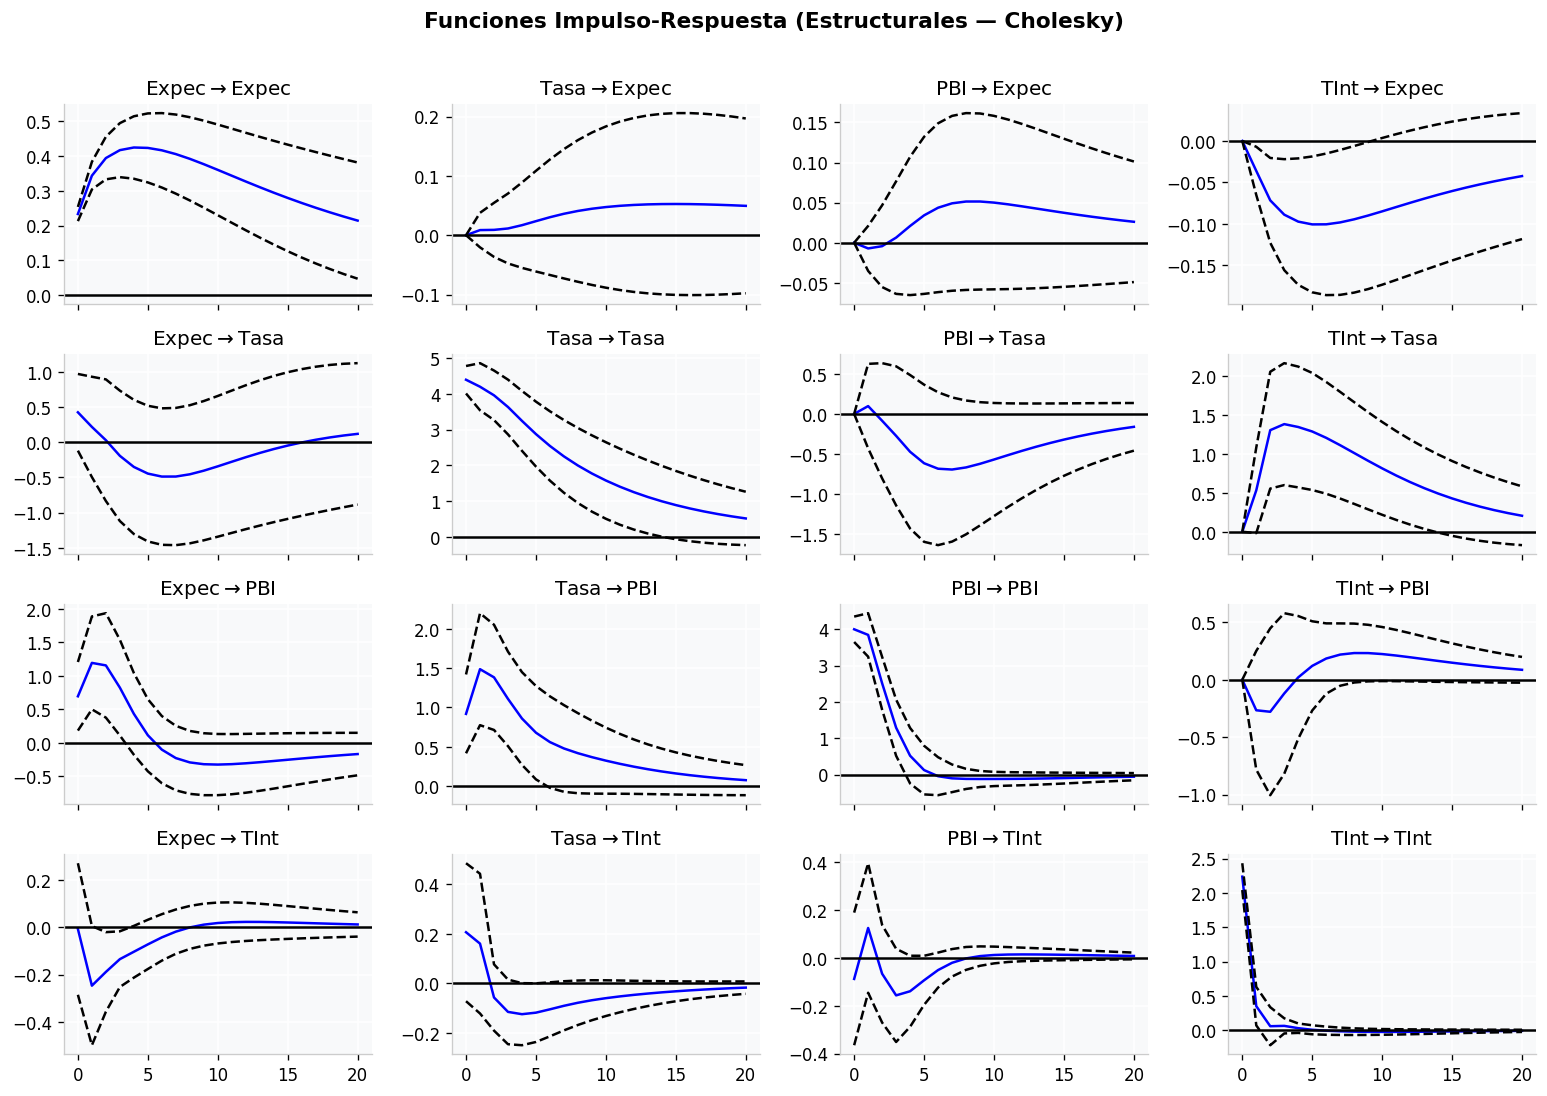

In [19]:
# Gráfico estándar de statsmodels
irf = plot_irf(results, VARS_, steps=IRF_STEPS, orth=True)

---
## 9 · FEVD — Descomposición de varianza

In [20]:
# Tabla a horizontes clave
tablas_fevd = tabla_fevd(results, VARS_, steps=IRF_STEPS,
                          horizontes=[1, 4, 8, 12, 20])


📊 DESCOMPOSICIÓN DE VARIANZA (FEVD)
   Horizonte máximo = 20  |  Identificación: Cholesky

  Variable dependiente: Expec
       Expec    Tasa     PBI    TInt
h=1   0.9918  0.0004  0.0003  0.0075
h=4   0.9647  0.0008  0.0008  0.0338
h=8   0.9465  0.0035  0.0061  0.0439
h=12  0.9378  0.0073  0.0092  0.0457

  Variable dependiente: Tasa
       Expec    Tasa     PBI    TInt
h=1   0.0061  0.9861  0.0003  0.0076
h=4   0.0047  0.9225  0.0038  0.0690
h=8   0.0111  0.8739  0.0183  0.0967
h=12  0.0131  0.8554  0.0258  0.1057

  Variable dependiente: PBI
       Expec    Tasa     PBI    TInt
h=1   0.0531  0.0853  0.8595  0.0020
h=4   0.0817  0.1382  0.7769  0.0032
h=8   0.0823  0.1569  0.7547  0.0061
h=12  0.0883  0.1611  0.7412  0.0095

  Variable dependiente: TInt
       Expec    Tasa     PBI    TInt
h=1   0.0115  0.0129  0.0044  0.9711
h=4   0.0231  0.0184  0.0132  0.9454
h=8   0.0242  0.0252  0.0152  0.9354
h=12  0.0244  0.0275  0.0152  0.9329


---
## 10 · Pronósticos


📈 Pronósticos (12 pasos adelante, IC 95%)
      Expec_F   Tasa_F   PBI_F  TInt_F
h+1    4.6370  55.5562  4.4485  0.7578
h+2    4.5549  56.1669  3.8859  0.4079
h+3    4.5009  56.2561  3.7755  0.3933
h+4    4.4609  56.2339  3.8590  0.3764
h+5    4.4283  56.2017  3.9974  0.3649
h+6    4.4002  56.1549  4.1243  0.3563
h+7    4.3755  56.0950  4.2164  0.3475
h+8    4.3534  56.0247  4.2748  0.3397
h+9    4.3334  55.9471  4.3086  0.3337
h+10   4.3153  55.8659  4.3270  0.3298
h+11   4.2986  55.7841  4.3364  0.3277
h+12   4.2831  55.7041  4.3410  0.3268


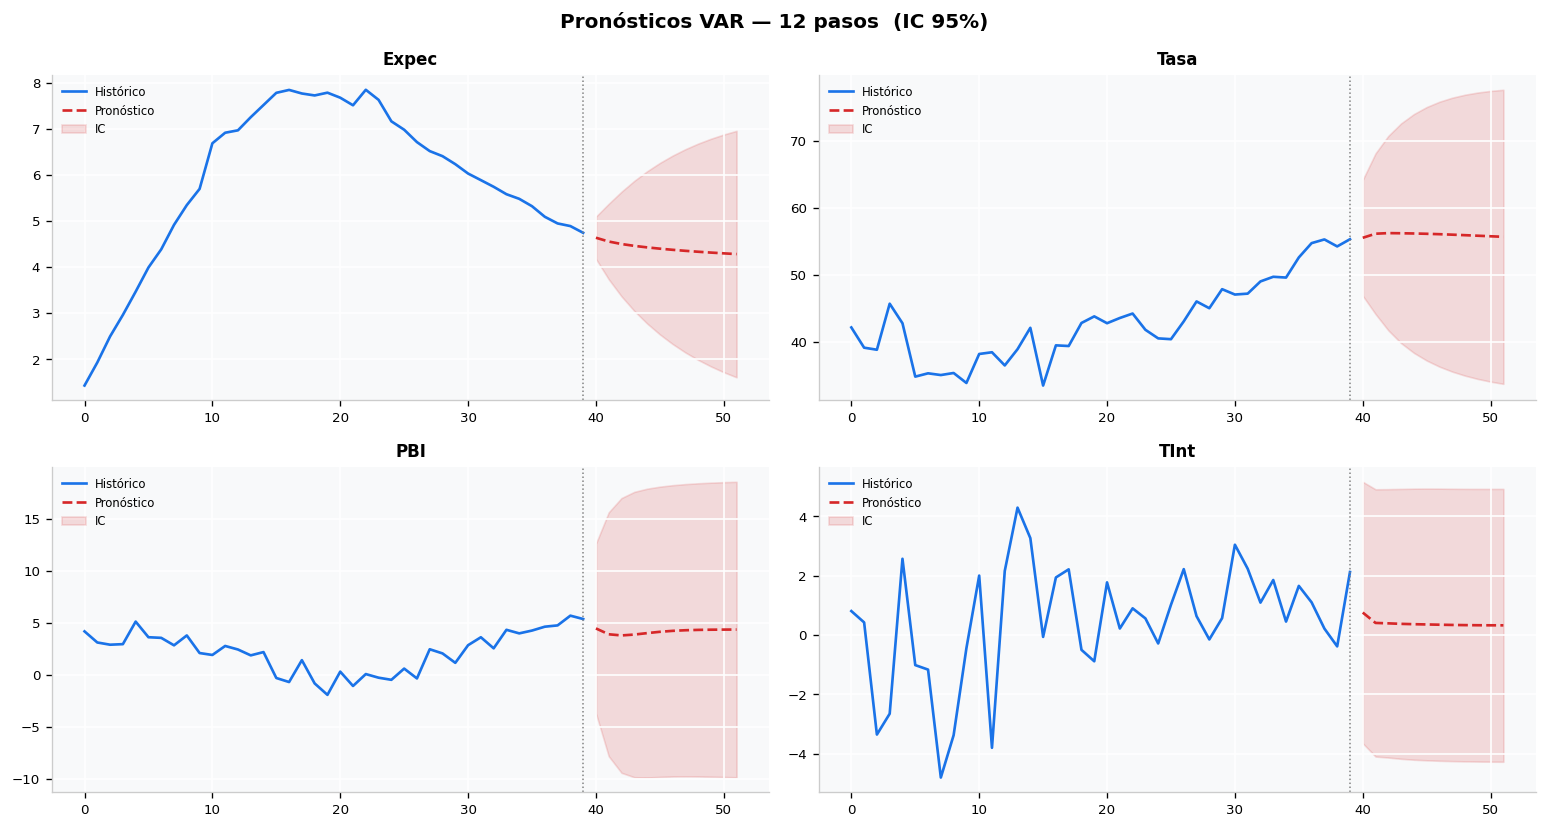

In [22]:
df_forecast = plot_pronosticos(
    results, data, VARS_,
    steps=FORE_STEPS,
    alpha=ALPHA,
    n_hist=40
)